# Timeline Pipeline Test

Experimental rap/timeline workflow. Parsing creates `df_timeline` and stable IDs only; MEI composition is a separate step where the Verovio rendering view is configured.

In [9]:
from pathlib import Path
import importlib.util
import sys

import pandas as pd
from IPython.display import SVG, display

MODULE_PATH = Path("camat/timeline_backend.py").resolve()
spec = importlib.util.spec_from_file_location("timeline_backend", MODULE_PATH)
timeline = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = timeline
spec.loader.exec_module(timeline)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## Parse To `df_timeline`

This step reads the Humdrum timeline data and creates stable IDs. It does not create MEI.

In [10]:
SOURCE_OPTIONS = {
    "lose_yourself": "https://raw.githubusercontent.com/Computational-Cognitive-Musicology-Lab/MCFlow/main/Humdrum/Eminem_LoseYourself.rap",
    "in_da_club": "https://raw.githubusercontent.com/Computational-Cognitive-Musicology-Lab/MCFlow/refs/heads/main/Humdrum/50Cent_InDaClub.rap",
}

# Change this key to select which source drives all downstream MEI and statistics cells.
ACTIVE_SOURCE = "in_da_club"
SOURCE = SOURCE_OPTIONS[ACTIVE_SOURCE]

parsed = timeline.parse_rap_humdrum_source(SOURCE)
df_timeline = parsed.df_timeline
metadata = parsed.metadata
SOURCE_LABEL = metadata.get("OTL") or ACTIVE_SOURCE.replace("_", " ").title()
SOURCE_SLUG = ACTIVE_SOURCE
df_timeline_rhythm = timeline.add_timeline_rhythm_analysis(df_timeline, label=SOURCE_LABEL, onset_bin_size="auto")

print(f"active source: {ACTIVE_SOURCE}")
print(f"url: {SOURCE}")
print(f"rows: {len(df_timeline)}")
print(f"columns: {len(df_timeline.columns)}")
print(f"title: {metadata.get('OTL')}")
print(f"composer: {metadata.get('COM')}")

active source: in_da_club
url: https://raw.githubusercontent.com/Computational-Cognitive-Musicology-Lab/MCFlow/refs/heads/main/Humdrum/50Cent_InDaClub.rap
rows: 387
columns: 40
title: In da Club
composer: Curtis James Jackson III


## Inspect Timeline Data

In [11]:
timeline_cols = [
    "section", "section_role", "measure", "local_onset", "global_onset", "duration",
    "duration_share", "onset_position", "onset_position_share",
    "lyric", "ipa", "stress", "tone", "break", "rhyme", "hype",
    "wordpos", "word_id", "xml_id_event", "xml_id_note", "xml_id_syl", "xml_id_annot",
]
display(df_timeline_rhythm[timeline_cols].head(20))

duration_counts = timeline.build_timeline_duration_counts(df_timeline, label=SOURCE_LABEL, normalize=True)
onset_position_counts, onset_position_summary = timeline.build_timeline_onset_position_counts(
    df_timeline,
    label=SOURCE_LABEL,
    bin_size="auto",
    normalize=True,
    edge_measure_mode="merge_to_regular",
)

display(duration_counts)
display(onset_position_counts)
print(f"regular measure span: {onset_position_summary['regular_span_quarters']} quarter lengths")

,section,section_role,measure,local_onset,global_onset,duration,duration_share,onset_position,onset_position_share,lyric,ipa,stress,tone,break,rhyme,hype,wordpos,word_id,xml_id_event,xml_id_note,xml_id_syl,xml_id_annot
0,Verse1,verse,0,0.00,0.00,2.00,0.002584,<NA>,<NA>,None,R,None,None,None,None,None,None,None,evt-verse1-m000-s0001,<NA>,<NA>,ann-verse1-m000-s0001
1,Verse1,verse,0,2.00,2.00,0.50,0.160207,<NA>,<NA>,None,R,None,None,None,None,None,None,None,evt-verse1-m000-s0002,<NA>,<NA>,ann-verse1-m000-s0002
2,Verse1,verse,0,2.50,2.50,0.25,0.832041,2.5,0.07438,When,wɜn,1,None,3,None,None,s,w-verse1-0001,evt-verse1-m000-s0003,n-verse1-m000-s0003,syl-verse1-m000-s0003,ann-verse1-m000-s0003
3,Verse1,verse,0,2.75,2.75,0.25,0.832041,2.75,0.071625,I,aI,0,None,None,None,None,s,w-verse1-0002,evt-verse1-m000-s0004,n-verse1-m000-s0004,syl-verse1-m000-s0004,ann-verse1-m000-s0004
4,Verse1,verse,0,3.00,3.00,0.25,0.832041,3.0,0.041322,pull,pʊl,1,None,None,None,None,s,w-verse1-0003,evt-verse1-m000-s0005,n-verse1-m000-s0005,syl-verse1-m000-s0005,ann-verse1-m000-s0005
5,Verse1,verse,0,3.25,3.25,0.25,0.832041,3.25,0.044077,up,əp,0,None,None,None,None,s,w-verse1-0004,evt-verse1-m000-s0006,n-verse1-m000-s0006,syl-verse1-m000-s0006,ann-verse1-m000-s0006
6,Verse1,verse,0,3.50,3.50,0.50,0.160207,3.5,0.07438,out,aʊt,1,None,None,None,None,s,w-verse1-0005,evt-verse1-m000-s0007,n-verse1-m000-s0007,syl-verse1-m000-s0007,ann-verse1-m000-s0007
7,Verse1,verse,1,0.00,4.00,0.25,0.832041,0.0,0.068871,front,frənt,1,None,None,None,None,s,w-verse1-0006,evt-verse1-m001-s0008,n-verse1-m001-s0008,syl-verse1-m001-s0008,ann-verse1-m001-s0008
8,Verse1,verse,1,0.25,4.25,0.25,0.832041,0.25,0.044077,you,ju,0,None,1,None,None,s,w-verse1-0007,evt-verse1-m001-s0009,n-verse1-m001-s0009,syl-verse1-m001-s0009,ann-verse1-m001-s0009
9,Verse1,verse,1,0.50,4.50,0.25,0.832041,0.5,0.07438,see,si,1,None,None,None,None,s,w-verse1-0008,evt-verse1-m001-s0010,n-verse1-m001-s0010,syl-verse1-m001-s0010,ann-verse1-m001-s0010


,source,duration,count_raw,share,count
0,In da Club,0.25,322,0.832041,0.832041
1,In da Club,0.50,62,0.160207,0.160207
2,In da Club,1.00,1,0.002584,0.002584
3,In da Club,1.50,1,0.002584,0.002584
4,In da Club,2.00,1,0.002584,0.002584


,source,meter_group,measure_count,measure_span_quarters,onset_position,count_raw,share,count
0,In da Club,4 quarter lengths,17,4.0,0.00,25,0.068871,0.068871
1,In da Club,4 quarter lengths,17,4.0,0.25,16,0.044077,0.044077
2,In da Club,4 quarter lengths,17,4.0,0.50,27,0.074380,0.074380
3,In da Club,4 quarter lengths,17,4.0,0.75,21,0.057851,0.057851
4,In da Club,4 quarter lengths,17,4.0,1.00,26,0.071625,0.071625
5,In da Club,4 quarter lengths,17,4.0,1.25,20,0.055096,0.055096
6,In da Club,4 quarter lengths,17,4.0,1.50,26,0.071625,0.071625
7,In da Club,4 quarter lengths,17,4.0,1.75,24,0.066116,0.066116
8,In da Club,4 quarter lengths,17,4.0,2.00,27,0.074380,0.074380
9,In da Club,4 quarter lengths,17,4.0,2.25,18,0.049587,0.049587


regular measure span: 4.0 quarter lengths


In [12]:
id_cols = ["xml_id_event", "xml_id_note", "xml_id_syl", "xml_id_annot"]
id_summary = []
for col in id_cols:
    values = df_timeline[col].dropna().astype(str)
    id_summary.append({
        "column": col,
        "non_null": len(values),
        "unique": values.nunique(),
        "duplicates": len(values) - values.nunique(),
    })

display(pd.DataFrame(id_summary))

,column,non_null,unique,duplicates
0,xml_id_event,387,387,0
1,xml_id_note,363,363,0
2,xml_id_syl,363,363,0
3,xml_id_annot,387,387,0


In [13]:
MEI_INFO_FIELD_SUMMARY = pd.DataFrame({
    "field": df_timeline_rhythm.columns,
    "non_null": [df_timeline_rhythm[c].notna().sum() for c in df_timeline_rhythm.columns],
    "example": [
        df_timeline_rhythm[c].dropna().iloc[0] if df_timeline_rhythm[c].notna().any() else None
        for c in df_timeline_rhythm.columns
    ],
})
display(MEI_INFO_FIELD_SUMMARY)

,field,non_null,example
0,source,387,https://raw.githubusercontent.com/Computationa...
1,row_number,387,6
2,event_index,387,1
3,section,387,Verse1
4,section_role,387,verse
5,section_index,387,1
6,measure,387,0
7,measure_index,387,0
8,local_onset,387,0.0
9,global_onset,387,0.0


## Compose MEI View

`lyric_info_fields` controls which timeline columns are rendered below the main lyric line. `lyric_info_layout="separate"` gives each field its own verse line and MEI `type`, so the rendered labels and XML stay interpretable without reparsing the source data.

In [14]:
MEI_INFO_FIELD_SUMMARY = pd.DataFrame([
    {"field": "stress", "label": "S", "meaning": "stress/accent annotation", "format": "text"},
    {"field": "break", "label": "B", "meaning": "break / phrase-boundary annotation", "format": "text"},
    {"field": "rhyme", "label": "R", "meaning": "rhyme-class annotation", "format": "text"},
    {"field": "ipa", "label": "IPA", "meaning": "phonetic transcription", "format": "text"},
    {"field": "tone", "label": "T", "meaning": "tone annotation when present", "format": "text"},
    {"field": "hype", "label": "H", "meaning": "hype / backing-vocal annotation", "format": "text"},
    {"field": "duration_token", "label": "Dur", "meaning": "original Humdrum reciprocal duration token", "format": "text"},
    {"field": "duration", "label": "DurQ", "meaning": "duration in quarter-note units", "format": "numeric"},
    {"field": "duration_share", "label": "D", "meaning": "share of this duration in the timeline", "format": "numeric"},
    {"field": "onset_position", "label": "Pos", "meaning": "onset position inside the measure", "format": "numeric"},
    {"field": "onset_position_share", "label": "O", "meaning": "share of this onset position in the timeline", "format": "numeric"},
    {"field": "wordpos", "label": "WP", "meaning": "MEI lyric word-position code", "format": "text"},
    {"field": "word_id", "label": "W", "meaning": "stable parsed word id", "format": "text"},
])

display(MEI_INFO_FIELD_SUMMARY)
print("Any column in df_timeline_rhythm can be listed in LYRIC_INFO_FIELDS:")
print(", ".join(df_timeline_rhythm.columns))

LYRIC_INFO_FIELDS = ["stress", "break", "rhyme", "duration_share", "onset_position_share"]
# Short labels keep the rendered analysis lines readable.
LYRIC_INFO_LABELS = {"stress": "S", "break": "B", "rhyme": "R", "duration_share": "D", "onset_position_share": "O"}
# Numeric formats use Python format specs: ".2f"/"2f" -> 0.07, ".0%" -> 7%, ".1%" -> 7.0%, ".3g" -> compact significant digits.
# LYRIC_INFO_MAX_VALUE_CHARS hard-limits the formatted value length after formatting.
LYRIC_INFO_VALUE_FORMATS = {"duration_share": ".2f", "onset_position_share": ".2f"}
LYRIC_INFO_MAX_VALUE_CHARS = 4

mei_text = timeline.timeline_to_mei(
    df_timeline_rhythm,
    metadata=metadata,
    staff_lines=1,
    show_clef=False,
    note_position="staff",
    note_loc=0,
    main_lyric_verse_n="1",
    lyric_info_fields=LYRIC_INFO_FIELDS,
    lyric_info_labels=LYRIC_INFO_LABELS,
    lyric_info_value_formats=LYRIC_INFO_VALUE_FORMATS,
    lyric_info_max_value_chars=LYRIC_INFO_MAX_VALUE_CHARS,
    lyric_info_verse_n="2",
    lyric_info_layout="separate",
    include_annotations=False,
    measures_per_system=2,
)

duplicate_xml_ids = timeline.find_duplicate_mei_xml_ids(mei_text)
display(duplicate_xml_ids)
print(f"duplicate xml:id count: {len(duplicate_xml_ids)}")

,field,label,meaning,format
0,stress,S,stress/accent annotation,text
1,break,B,break / phrase-boundary annotation,text
2,rhyme,R,rhyme-class annotation,text
3,ipa,IPA,phonetic transcription,text
4,tone,T,tone annotation when present,text
5,hype,H,hype / backing-vocal annotation,text
6,duration_token,Dur,original Humdrum reciprocal duration token,text
7,duration,DurQ,duration in quarter-note units,numeric
8,duration_share,D,share of this duration in the timeline,numeric
9,onset_position,Pos,onset position inside the measure,numeric


Any column in df_timeline_rhythm can be listed in LYRIC_INFO_FIELDS:
source, row_number, event_index, section, section_role, section_index, measure, measure_index, local_onset, global_onset, duration, duration_token, duration_base, duration_dots, duration_modifier, meter, tempo_bpm, lyric, ipa, stress, tone, break, rhyme, hype, is_rest, wordpos, word_id, xml_id_event, xml_id_note, xml_id_syl, xml_id_annot, duration_count_raw, duration_share, duration_count, onset_position, onset_position_count_raw, onset_position_share, onset_position_count, spine_recip, spine_lyrics


,xml_id,count


duplicate xml:id count: 0


## Save MEI

In [15]:
out_dir = Path("exports/timeline")
mei_path = out_dir / f"{SOURCE_SLUG}.timeline.mei"

timeline.save_timeline_mei(
    df_timeline_rhythm,
    mei_path,
    metadata=metadata,
    staff_lines=1,
    show_clef=False,
    note_position="staff",
    note_loc=0,
    main_lyric_verse_n="1",
    lyric_info_fields=LYRIC_INFO_FIELDS,
    lyric_info_labels=LYRIC_INFO_LABELS,
    lyric_info_value_formats=LYRIC_INFO_VALUE_FORMATS,
    lyric_info_max_value_chars=LYRIC_INFO_MAX_VALUE_CHARS,
    lyric_info_verse_n="2",
    lyric_info_layout="separate",
    include_annotations=False,
    measures_per_system=4,
)

print(mei_path)
print(mei_text[:1600])

exports\timeline\in_da_club.timeline.mei
<?xml version="1.0" encoding="UTF-8"?>
<mei xmlns="http://www.music-encoding.org/ns/mei" meiversion="5.0">
  <meiHead>
    <fileDesc>
      <titleStmt>
        <title>In da Club</title>
      </titleStmt>
      <pubStmt><p>Generated by CAMAT timeline_backend.</p></pubStmt>
    </fileDesc>
    <workList>
      <work>
        <title>In da Club</title>
        <composer>
          <persName>Curtis James Jackson III</persName>
        </composer>
      </work>
    </workList>
  </meiHead>
  <music>
    <body>
      <mdiv>
        <score>
          <scoreDef meter.count="4" meter.unit="4">
            <staffGrp>
              <staffDef n="1" lines="1"/>
            </staffGrp>
          </scoreDef>
          <section xml:id="sec-verse1" label="Verse1" type="verse">
            <measure xml:id="measure-verse1-000" n="0">
              <staff n="1">
                <layer n="1">
                  <rest xml:id="evt-verse1-m000-s0001" dur="2"/>
         

## Render Generated MEI In Verovio

loaded: True
pages: 1


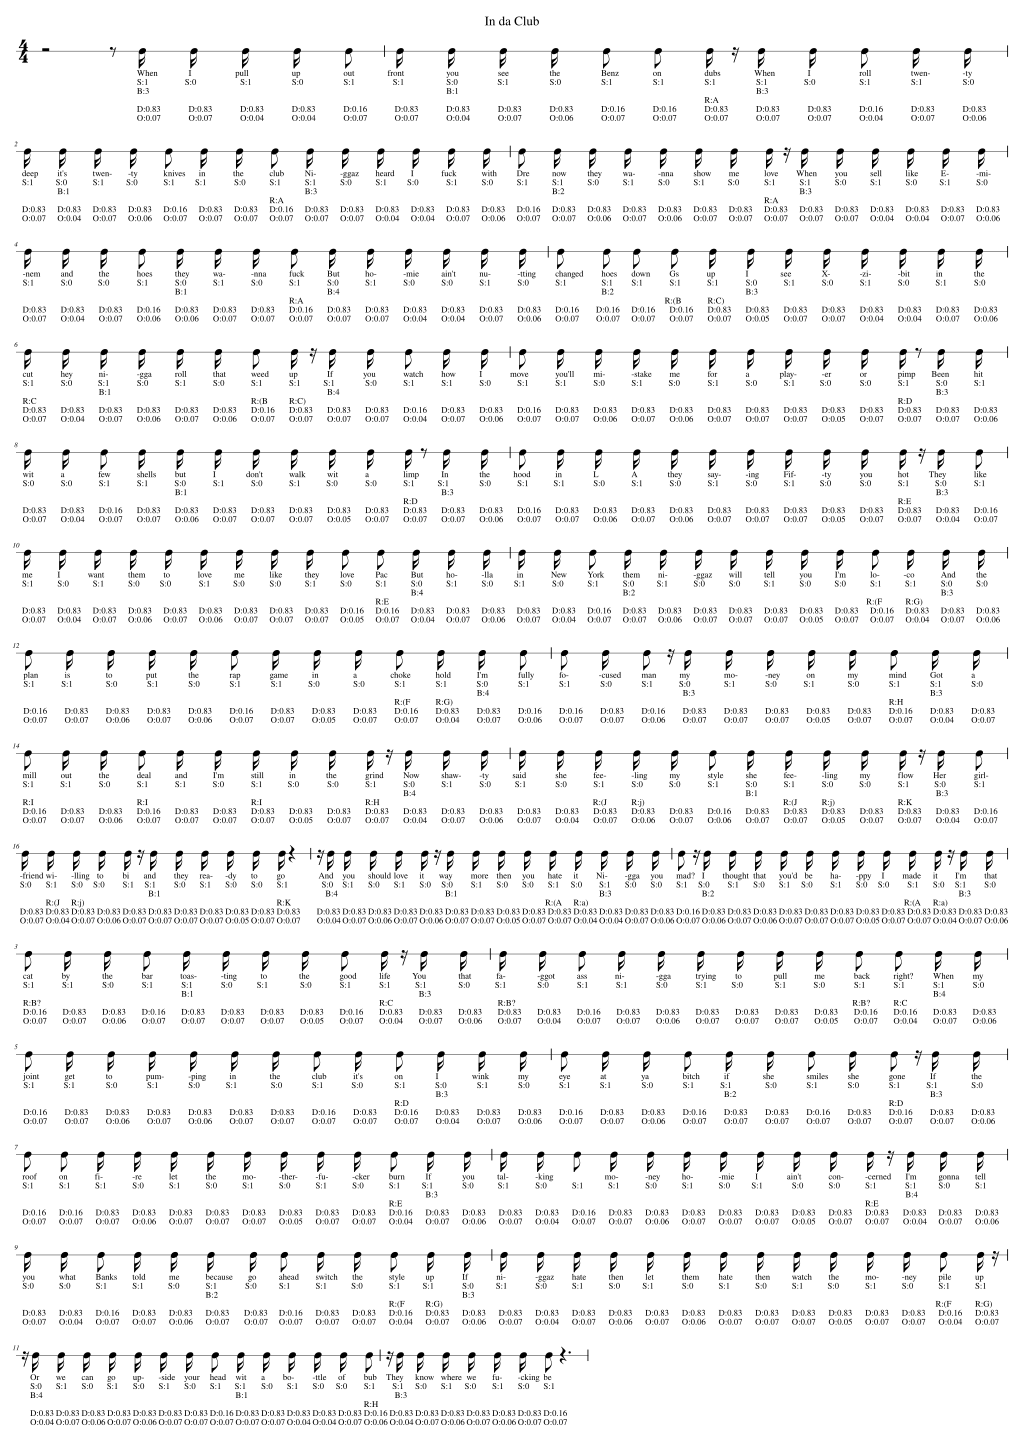

In [16]:
import verovio

tk = verovio.toolkit()
tk.setOptions({
    "inputFrom": "mei",
    "breaks": "encoded",
    "pageWidth": 3200,
    "pageHeight": 2100,
    "scale": 32,
    "adjustPageHeight": True,
    "lyricSize": 3.0,
    "lyricVerseCollapse": True,
})

loaded = tk.loadData(mei_text)
page_count = tk.getPageCount()
print(f"loaded: {loaded}")
print(f"pages: {page_count}")

display(SVG(tk.renderToSVG(1)))

In [17]:
if page_count > 1:
    display(SVG(tk.renderToSVG(2)))

## Timeline Duration Distribution

In [18]:
from camat.analysis_utils import display_duration_distribution


# Configuration for this cell
TIMELINE_DURATION_INCLUDE_RESTS = True
TIMELINE_DURATION_DROP_ZERO = True
TIMELINE_DURATION_ROUND_DECIMALS = 4
TIMELINE_DURATION_NORMALIZE = True
TIMELINE_DURATION_FLOAT_FORMAT = "3f"
TIMELINE_DURATION_BAR_COLOR = "#4682B4"
TIMELINE_STATS_BACKEND = "bokeh"  # "plt" | "bokeh" | "none"

duration_source_df = df_timeline_rhythm.copy()
if not TIMELINE_DURATION_INCLUDE_RESTS and "is_rest" in duration_source_df.columns:
    duration_source_df = duration_source_df[~duration_source_df["is_rest"].fillna(False).astype(bool)].copy()

timeline_duration_counts = display_duration_distribution(
    duration_source_df,
    drop_zero=TIMELINE_DURATION_DROP_ZERO,
    round_decimals=TIMELINE_DURATION_ROUND_DECIMALS,
    backend=TIMELINE_STATS_BACKEND,
    plot_width=1200,
    plot_height=350,
    show_hover=True,
    show_table=True,
    bar_color=TIMELINE_DURATION_BAR_COLOR,
    normalize=TIMELINE_DURATION_NORMALIZE,
    float_format=TIMELINE_DURATION_FLOAT_FORMAT,
)

display(timeline_duration_counts)

,count_raw,share
duration,,
0.250,322,0.832
0.500,62,0.160
1.000,1,0.003
1.500,1,0.003
2.000,1,0.003


Loading BokehJS ...

,duration,count,count_raw
0,0.25,0.832041,322
1,0.50,0.160207,62
2,1.00,0.002584,1
3,1.50,0.002584,1
4,2.00,0.002584,1


## Timeline Onset Position Histogram

In [19]:
from camat.analysis_utils import display_onset_position_histogram


# Configuration for this cell
TIMELINE_ONSET_BIN_SIZE = "auto"  # "auto" or a fixed grid such as 0.25
TIMELINE_ONSET_NORMALIZE = True
TIMELINE_ONSET_INCLUDE_RESTS = False
TIMELINE_ONSET_EDGE_MEASURE_MODE = "merge_to_regular"  # "merge_to_regular" | "split_by_span"
TIMELINE_ONSET_SHOW_MEASURE_DEBUG = True
TIMELINE_ONSET_FLOAT_FORMAT = "3f"
TIMELINE_ONSET_BAR_COLOR = "#2E8B57"

timeline_onset_source_df = df_timeline_rhythm.copy()
if not TIMELINE_ONSET_INCLUDE_RESTS and "is_rest" in timeline_onset_source_df.columns:
    timeline_onset_source_df = timeline_onset_source_df[
        ~timeline_onset_source_df["is_rest"].fillna(False).astype(bool)
    ].copy()

timeline_measure_offsets = (
    df_timeline_rhythm.sort_values(["section_index", "measure_index", "event_index"], kind="stable")
    .groupby(["section_index", "measure_index"], sort=False)["global_onset"]
    .min()
    .astype(float)
    .round(6)
    .tolist()
)

if str(TIMELINE_ONSET_BIN_SIZE).strip().lower() == "auto":
    positive_durations = pd.to_numeric(timeline_onset_source_df["duration"], errors="coerce")
    positive_durations = positive_durations[positive_durations > 0]
    TIMELINE_ONSET_RESOLVED_BIN_SIZE = float(positive_durations.min()) if len(positive_durations) else 0.25
else:
    TIMELINE_ONSET_RESOLVED_BIN_SIZE = float(TIMELINE_ONSET_BIN_SIZE)

timeline_onset_counts = display_onset_position_histogram(
    timeline_onset_source_df,
    source_labels=[SOURCE_LABEL],
    reference_dfs=[df_timeline_rhythm],
    measure_offsets=[timeline_measure_offsets],
    bin_size=TIMELINE_ONSET_RESOLVED_BIN_SIZE,
    normalize=TIMELINE_ONSET_NORMALIZE,
    edge_measure_mode=TIMELINE_ONSET_EDGE_MEASURE_MODE,
    use_measure_metadata=False,
    backend=TIMELINE_STATS_BACKEND,
    plot_width=1200,
    plot_height=350,
    show_hover=True,
    show_table=True,
    show_measure_debug=TIMELINE_ONSET_SHOW_MEASURE_DEBUG,
    bar_color=TIMELINE_ONSET_BAR_COLOR,
    float_format=TIMELINE_ONSET_FLOAT_FORMAT,
)

display(timeline_onset_counts)

=== Onset Position Histogram (In da Club) ===
Measures represented: 29
Measure start source: measure_offsets
Time signature / measure span(s): ~4/4 (4.000 quarter lengths), 4.250 quarter lengths
Regular inferred span: 4.000 quarter lengths
Total loaded-source distance: 116.000 quarter lengths
MEI measure metadata rows: 0
Edge measure mode: merge_to_regular
Metadata-informed handling: incomplete_final_left_aligned_inferred, regular, short_internal_merged
Smallest detected onset-position step: 0.250 quarter lengths
Measure handling debug:


,inferred_measure_index,measure_start,measure_span_quarters,display_span_quarters,measure_handling,measure_type,measure_metcon,measure_join,measure_n,first_onset_within_measure,last_onset_within_measure,onset_count
0,1,0.000,4.000,4.000,regular,None,None,None,None,2.500,3.500,5
1,2,4.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,12
2,3,8.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,14
3,4,12.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,14
4,5,16.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,14
5,6,20.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,12
6,7,24.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,13
7,8,28.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,13
8,9,32.000,4.000,4.000,regular,None,None,None,None,0.000,3.750,13
9,10,36.000,4.000,4.000,regular,None,None,None,None,0.000,3.500,13


,source,time_signature_info,measure_count,total_distance_quarters,measure_start_source,measure_handling,onset_within_measure,count_raw,share,count
0,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,0.000,1,0.037,0.037
1,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,0.250,1,0.037,0.037
2,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,0.500,2,0.074,0.074
3,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,0.750,2,0.074,0.074
4,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,1.000,2,0.074,0.074
5,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,1.250,2,0.074,0.074
6,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,1.500,2,0.074,0.074
7,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,1.750,1,0.037,0.037
8,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,2.000,2,0.074,0.074
9,In da Club,4.250 quarter lengths,2,116.000,measure_offsets,regular,2.250,1,0.037,0.037


Drawing separate combined plot for 4.250 quarter lengths.


Loading BokehJS ...

Drawing separate combined plot for ~4/4 (4.000 quarter lengths).


Loading BokehJS ...

,source,meter_group,time_signature_info,measure_count,total_distance_quarters,measure_start_source,measure_span_quarters,measure_handling,onset_within_measure,count_raw,share,count
0,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,0.00,1,0.037037,0.037037
1,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,0.25,1,0.037037,0.037037
2,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,0.50,2,0.074074,0.074074
3,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,0.75,2,0.074074,0.074074
4,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,1.00,2,0.074074,0.074074
5,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,1.25,2,0.074074,0.074074
6,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,1.50,2,0.074074,0.074074
7,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,1.75,1,0.037037,0.037037
8,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,2.00,2,0.074074,0.074074
9,In da Club,4.250 quarter lengths,4.250 quarter lengths,2,116.0,measure_offsets,4.25,regular,2.25,1,0.037037,0.037037
